You're a Data Scientist working for a national music broadcaster. With the
Eurovision Song Contest approaching, the strategy team wants to use data to
understand what makes a song successful. Your mission is to build a "Success
Calculator" that can predict the total points a song might receive based on its
characteristics, such as tempo, danceability, and artist type.

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df=pd.read_excel('/content/dataset.xlsx')

In [85]:
df

,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,...,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,...,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,...,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762
3,4,2009,Sweden,Scandinavia,Malena Ernman,La voix,Female,Solo,21,33,...,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692
4,5,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,Both,Group,18,45,...,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,644,2010,Slovenia,Former Yugoslavia,Ansambel _lindra¾and¾Kalamari,Narodnozabavni rock,NaN,NaN,16,6,...,0.657474,129.953,0.042575,9.0,0.063622,4.0,1.0,-3.223,0.687482,NaN
644,645,2010,Sweden,Scandinavia,Anna Bergendahl,This Is My Life,NaN,NaN,11,62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
645,646,2010,Switzerland,Western Europe,Michael von der Heide,Il pleut de l'or,NaN,NaN,17,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
646,647,2010,Turkey,Independent,maNga,We Could Be the Same,NaN,NaN,1,118,...,0.660555,133.032,0.044043,2.0,0.033176,4.0,0.0,-4.891,0.565634,5.599667


# Data Cleaning & Preparation & EDA

In [86]:
df.head()

,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,...,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,...,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,...,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762
3,4,2009,Sweden,Scandinavia,Malena Ernman,La voix,Female,Solo,21,33,...,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692
4,5,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,Both,Group,18,45,...,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,NaN


In [87]:
df.tail()

,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
643,644,2010,Slovenia,Former Yugoslavia,Ansambel _lindra¾and¾Kalamari,Narodnozabavni rock,NaN,NaN,16,6,...,0.657474,129.953,0.042575,9.0,0.063622,4.0,1.0,-3.223,0.687482,NaN
644,645,2010,Sweden,Scandinavia,Anna Bergendahl,This Is My Life,NaN,NaN,11,62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
645,646,2010,Switzerland,Western Europe,Michael von der Heide,Il pleut de l'or,NaN,NaN,17,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
646,647,2010,Turkey,Independent,maNga,We Could Be the Same,NaN,NaN,1,118,...,0.660555,133.032,0.044043,2.0,0.033176,4.0,0.0,-4.891,0.565634,5.599667
647,648,2010,Ukraine,Former Socialist Bloc,Alyosha,Sweet People,NaN,NaN,7,77,...,0.661755,119.954,0.037064,0.0,0.176192,4.0,1.0,-6.866,0.208532,5.603956


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         648 non-null    int64  
 1   Year               648 non-null    int64  
 2   Country            648 non-null    object 
 3   Region             648 non-null    object 
 4   Artist             648 non-null    object 
 5   Song               648 non-null    object 
 6   Artist.gender      226 non-null    object 
 7   Group.Solo         226 non-null    object 
 8   Place              648 non-null    int64  
 9   Points             648 non-null    int64  
 10  Home.Away.Country  648 non-null    object 
 11  Home.Away.Region   648 non-null    object 
 12  Is.Final           648 non-null    int64  
 13  Semi.Final.Number  281 non-null    float64
 14  Song.In.English    648 non-null    int64  
 15  Song.Quality       648 non-null    float64
 16  Normalized.Points  648 non

In [89]:
df.describe()

,Unnamed: 0,Year,Place,Points,Is.Final,Semi.Final.Number,Song.In.English,Song.Quality,Normalized.Points,energy,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
count,648.000000,648.000000,648.000000,648.000000,648.000000,281.000000,648.000000,648.000000,648.000000,482.000000,...,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,480.000000,304.000000
mean,324.500000,2006.543210,11.858025,77.783951,0.566358,1.327402,0.728395,2.636140,0.044753,0.725833,...,0.571246,113.905349,0.056576,5.782158,0.201399,3.900415,0.580913,-6.516718,0.521286,5.406843
std,187.205769,4.016733,6.795186,63.301464,0.495960,0.470103,0.445131,2.089733,0.034887,0.186675,...,0.136131,24.958535,0.050582,3.453922,0.172561,0.485164,0.493922,2.358372,0.236548,0.288879
min,1.000000,1998.000000,1.000000,0.000000,0.000000,1.000000,0.000000,-0.424200,0.000000,0.064730,...,0.183719,64.971000,0.023994,0.000000,0.026513,1.000000,0.000000,-21.878000,0.017786,4.375630
25%,162.750000,2004.000000,6.000000,30.000000,0.000000,1.000000,0.000000,1.017664,0.017946,0.607444,...,0.489436,91.968500,0.032869,2.250000,0.090076,4.000000,0.000000,-7.735000,0.328387,5.251099
50%,324.500000,2007.000000,12.000000,62.000000,1.000000,1.000000,1.000000,2.054728,0.035151,0.759969,...,0.574584,121.357500,0.041742,6.000000,0.136240,4.000000,1.000000,-6.169500,0.525902,5.464790
75%,486.250000,2010.000000,17.000000,110.000000,1.000000,2.000000,1.000000,3.864811,0.065451,0.881004,...,0.669654,130.163000,0.060256,9.000000,0.277933,4.000000,1.000000,-4.894000,0.723856,5.579380
max,648.000000,2012.000000,28.000000,387.000000,1.000000,2.000000,1.000000,9.795199,0.158867,0.999169,...,0.894179,211.985000,0.505107,11.000000,0.987510,7.000000,1.000000,-2.352000,0.971989,6.148232


In [90]:
df.describe(include=['object','category'])

,Country,Region,Artist,Song,Artist.gender,Group.Solo,Home.Away.Country,Home.Away.Region
count,648,648,648,648,226,226,648,648
unique,48,5,530,509,3,2,2,2
top,Turkey,Former Socialist Bloc,Jedward,Angel,Female,Solo,Away,Away
freq,21,213,4,4,101,153,634,512


In [91]:
df.shape

(648, 30)

Target Column:**Points**

Since the target column has continuous numerical values it is a **Supervised Regression Problem**.

**Problem Statement**:Predict the total points a song might receive based on its characteristics, such as tempo, danceability, and artist type

In [92]:
df['Points'].value_counts()

,count
Points,
53,11
45,11
36,10
22,9
18,9
...,...
103,1
20,1
181,1


In [93]:
num_col=df.select_dtypes(include=['int64','float64']).columns
num_col

Index(['Unnamed: 0', 'Year', 'Place', 'Points', 'Is.Final',
       'Semi.Final.Number', 'Song.In.English', 'Song.Quality',
       'Normalized.Points', 'energy', 'duration', 'acousticness',
       'danceability', 'tempo', 'speechiness', 'key', 'liveness',
       'time_signature', 'mode', 'loudness', 'valence', 'Happiness'],
      dtype='object')

In [94]:
cat_col=df.select_dtypes(include=['object','category']).columns
cat_col

Index(['Country', 'Region', 'Artist', 'Song', 'Artist.gender', 'Group.Solo',
       'Home.Away.Country', 'Home.Away.Region'],
      dtype='object')

In [95]:
# null value checking
df.isna().sum()

,0
Unnamed: 0,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Artist.gender,422
Group.Solo,422
Place,0
Points,0


In [56]:
df['Home.Away.Country']

,Home.Away.Country
0,Away
1,Away
2,Away
3,Away
4,Away
...,...
643,Away
644,Away
645,Away
646,Away


In [14]:
# duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# Artist.gender,Group.Solo,Semi.Final.Number,(energy,duration,acousticness,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence),Happiness

In [15]:
(166/648)*100

25.617283950617285

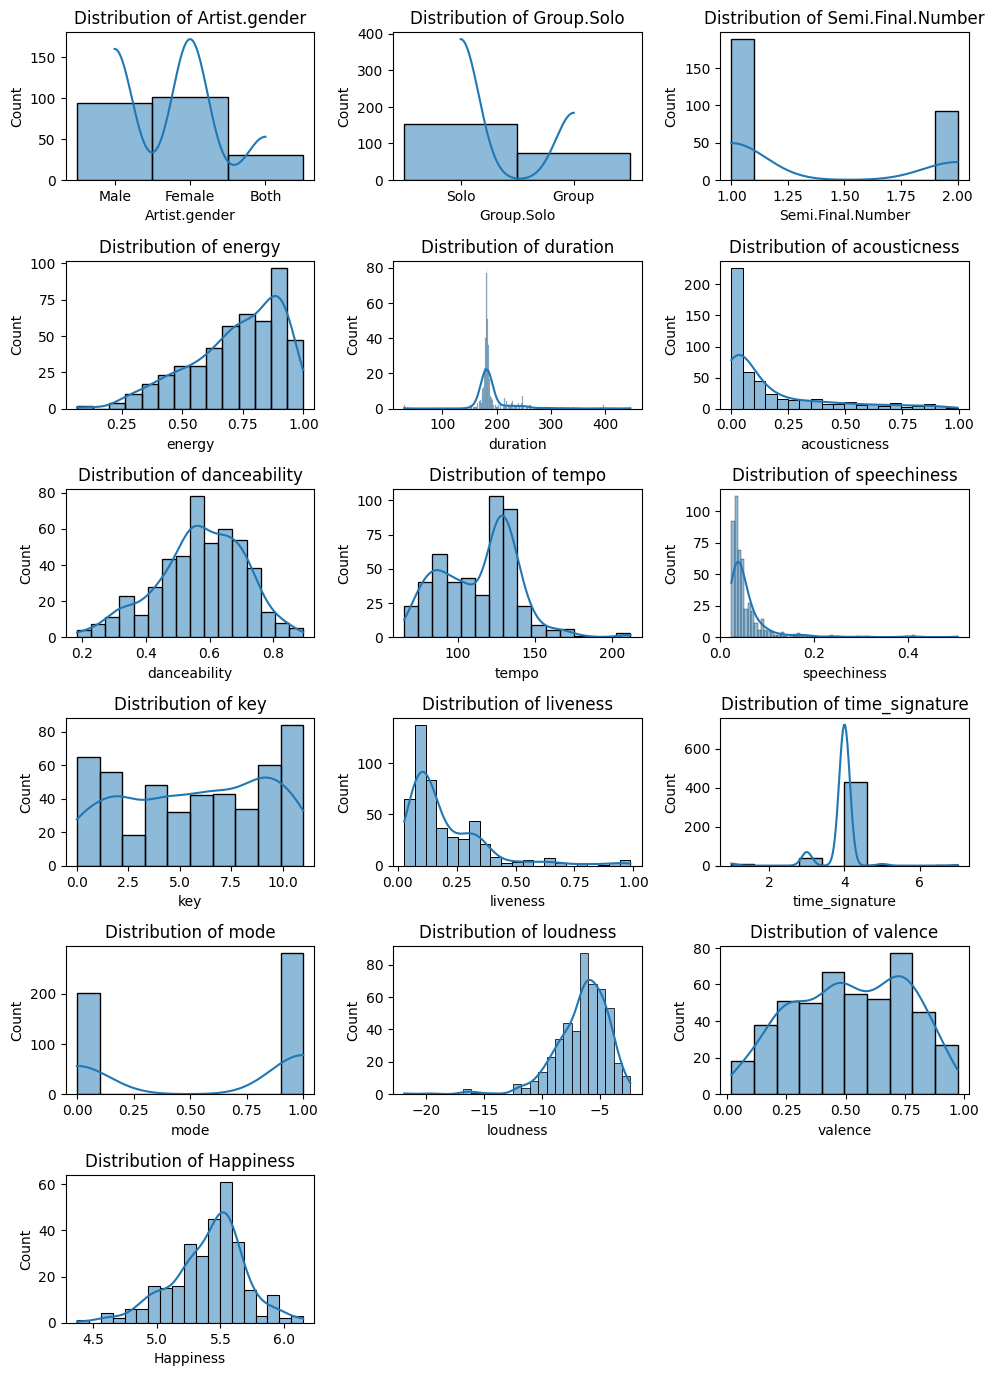

In [32]:
columns=['Artist.gender','Group.Solo','Semi.Final.Number','energy','duration','acousticness','danceability','tempo','speechiness','key','liveness','time_signature','mode','loudness','valence','Happiness']
plt.figure(figsize=(10,18))
for i,col in enumerate(columns,1):
  plt.subplot(8,3,i)
  sns.histplot(df[col],kde=True)
  plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [96]:
# categorical-mode
df['Artist.gender'] = df['Artist.gender'].fillna(df['Artist.gender'].mode()[0])

In [97]:
# binary category
df['Group.Solo'] = df['Group.Solo'].fillna(df['Group.Solo'].mode()[0])

In [98]:
df['Semi.Final.Number'] = df['Semi.Final.Number'].fillna(df['Semi.Final.Number'].mode()[0])

In [99]:
#left skewed- median
df['energy'] = df['energy'].fillna(df['energy'].median())

In [100]:
# normal distribution
df['duration'] = df['duration'].fillna(df['duration'].mean())

In [101]:
# right skewed
df['acousticness'] = df['acousticness'].fillna(df['acousticness'].median())

In [102]:
# normal distribution
df['danceability'] = df['danceability'].fillna(df['danceability'].mean())

In [103]:
df['tempo'] = df['tempo'].fillna(df['tempo'].median())

In [104]:
# right skewed
df['speechiness'] = df['speechiness'].fillna(df['speechiness'].median())

In [105]:
df['key'] = df['key'].fillna(df['key'].median())

In [106]:
df['time_signature'] = df['time_signature'].fillna(df['time_signature'].median())

In [107]:
# right skewed
df['liveness'] = df['liveness'].fillna(df['liveness'].median())

In [108]:
# either 0 or 1
df['mode'] = df['mode'].fillna(df['mode'].mode()[0])

In [109]:
# left skewed- median
df['loudness'] = df['loudness'].fillna(df['loudness'].median())

In [110]:
# uneven distribution hence median
df['valence'] = df['valence'].fillna(df['valence'].median())

In [111]:
# since normally distributed in the histplot filling with mean
df['Happiness'] = df['Happiness'].fillna(df['Happiness'].mean())

In [112]:
df.isna().sum()

,0
Unnamed: 0,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Artist.gender,0
Group.Solo,0
Place,0
Points,0


<Axes: ylabel='energy'>

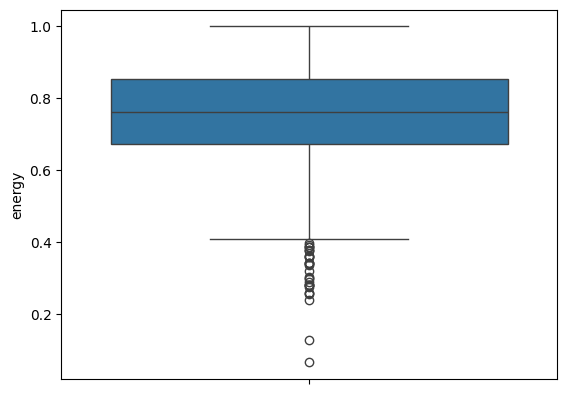

In [50]:
sns.boxplot(df['energy'])

<Axes: ylabel='loudness'>

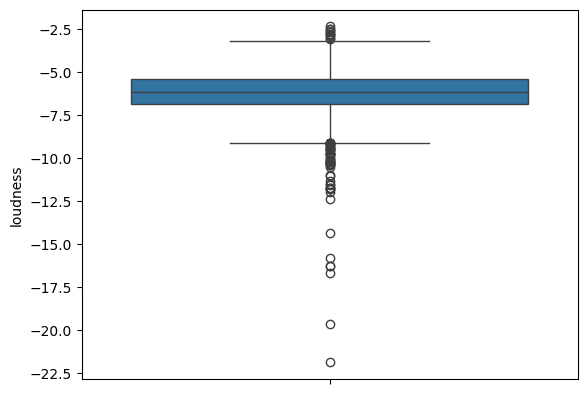

In [51]:
sns.boxplot(df['loudness'])

# Feature engineering

In [113]:
# index there already, points is our target so no need normalized
# Song and Artist are text columns which is not required for predicting song success directly it should be handelled in another way like NLP
# Since using region dropping country
df = df.drop(columns=['Unnamed: 0','Home.Away.Country','Home.Away.Region','Normalized.Points','Song','Artist','Country'], errors='ignore')

In [132]:
num_cols_new=['Year', 'Place', 'Is.Final',
       'Semi.Final.Number', 'Song.In.English', 'Song.Quality','energy', 'duration', 'acousticness',
       'danceability', 'tempo', 'speechiness', 'key', 'liveness',
       'time_signature', 'mode', 'loudness', 'valence', 'Happiness']

In [133]:
cat_cols_new=['Region','Artist.gender', 'Group.Solo']

In [116]:
df['Region'].value_counts()

,count
Region,
Former Socialist Bloc,213
Western Europe,168
Scandinavia,90
Independent,89
Former Yugoslavia,88


Text(0.5, 1.0, 'Artist.gender vs Points')

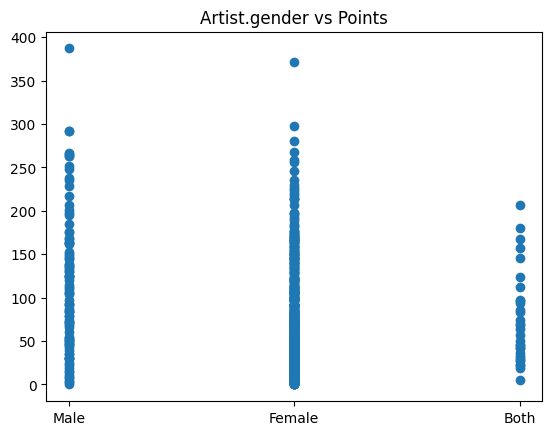

In [117]:
plt.scatter(x='Artist.gender',y='Points',data=df)
plt.title('Artist.gender vs Points')

Text(0.5, 1.0, 'Group.Solo vs Points')

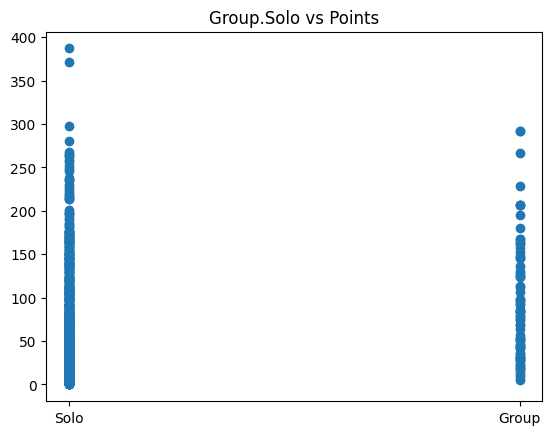

In [118]:
plt.scatter(x='Group.Solo',y='Points',data=df)
plt.title('Group.Solo vs Points')

Text(0.5, 1.0, 'Danceability vs Points')

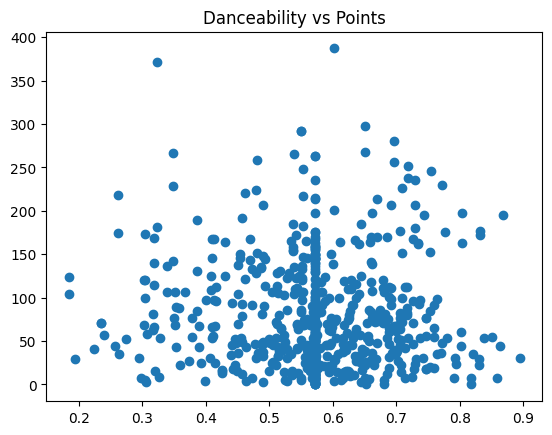

In [119]:
plt.scatter(x='danceability',y='Points',data=df)
plt.title('Danceability vs Points')

- From this plot it is found those songs with low(0.3) to moderate(0.6) danceablitity has received the highest of around 400 points
- Songs of very low and high danceability score of 0.2 or 0.9 has received the lowest points below 50.
- Most of the songs fall under moderate danceability of 0.3 to 0.7 and has received points also moderately between 100 to 300.

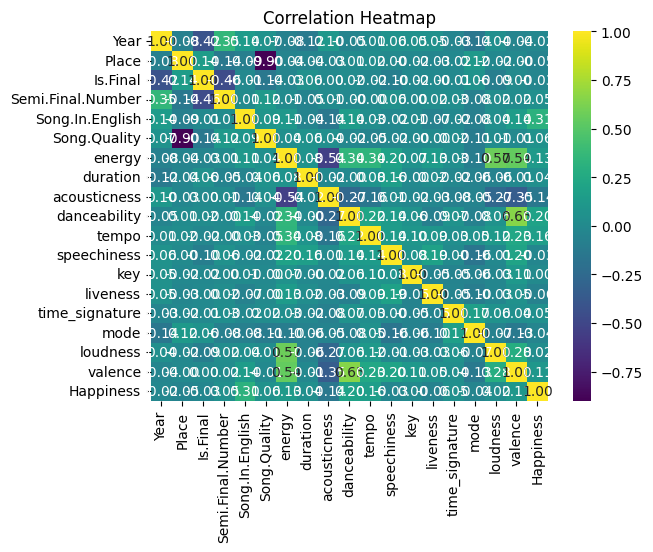

In [134]:
corr_mat=df[num_cols_new].corr()
sns.heatmap(corr_mat,annot=True, fmt='.2f',cmap = 'viridis')
plt.title('Correlation Heatmap')
plt.show()

In [135]:
X= df.drop('Points',axis=1)
y= df['Points']

In [136]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor= ColumnTransformer(transformers=[
    ('num',StandardScaler(),num_cols_new),
    ('cat',OneHotEncoder(),cat_cols_new)
])

In [141]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df['Points'] = scaler.fit_transform(df[['Points']])

In [137]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (518, 22)
Test set: (130, 22)


# Model Selection

In [158]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

pipeline=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("regressor",GradientBoostingRegressor())
])

In [159]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Place', 'Is.Final',
                                                   'Semi.Final.Number',
                                                   'Song.In.English',
                                                   'Song.Quality', 'energy',
                                                   'duration', 'acousticness',
                                                   'danceability', 'tempo',
                                                   'speechiness', 'key',
                                                   'liveness', 'time_signature',
                                                   'mode', 'loudness',
                                                   'valence', 'Happiness']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Region', 'Artist.gender',
                                                   'Group.Solo'])])),
                ('regressor', GradientBoostingRegressor())])

In [160]:
y_pred_gb=pipeline.predict(X_test)

In [161]:
pipeline2=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("regressor2",LinearRegression())
])

In [162]:
pipeline2.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Place', 'Is.Final',
                                                   'Semi.Final.Number',
                                                   'Song.In.English',
                                                   'Song.Quality', 'energy',
                                                   'duration', 'acousticness',
                                                   'danceability', 'tempo',
                                                   'speechiness', 'key',
                                                   'liveness', 'time_signature',
                                                   'mode', 'loudness',
                                                   'valence', 'Happiness']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Region', 'Artist.gender',
                                                   'Group.Solo'])])),
                ('regressor2', LinearRegression())])

In [163]:
y_pred_lr=pipeline2.predict(X_test)

In [164]:
pipeline3=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("regressor3",KNeighborsRegressor(n_neighbors=5))
])

In [165]:
pipeline3.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Place', 'Is.Final',
                                                   'Semi.Final.Number',
                                                   'Song.In.English',
                                                   'Song.Quality', 'energy',
                                                   'duration', 'acousticness',
                                                   'danceability', 'tempo',
                                                   'speechiness', 'key',
                                                   'liveness', 'time_signature',
                                                   'mode', 'loudness',
                                                   'valence', 'Happiness']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Region', 'Artist.gender',
                                                   'Group.Solo'])])),
                ('regressor3', KNeighborsRegressor())])

In [166]:
y_pred_knn=pipeline3.predict(X_test)

In [167]:
pipeline4=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("regressor4",SVR())
])

In [168]:
pipeline4.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Place', 'Is.Final',
                                                   'Semi.Final.Number',
                                                   'Song.In.English',
                                                   'Song.Quality', 'energy',
                                                   'duration', 'acousticness',
                                                   'danceability', 'tempo',
                                                   'speechiness', 'key',
                                                   'liveness', 'time_signature',
                                                   'mode', 'loudness',
                                                   'valence', 'Happiness']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Region', 'Artist.gender',
                                                   'Group.Solo'])])),
                ('regressor4', SVR())])

In [169]:
y_pred_svr=pipeline4.predict(X_test)

In [170]:
pipeline5=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("regressor5",DecisionTreeRegressor())
])

In [171]:
pipeline5.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Place', 'Is.Final',
                                                   'Semi.Final.Number',
                                                   'Song.In.English',
                                                   'Song.Quality', 'energy',
                                                   'duration', 'acousticness',
                                                   'danceability', 'tempo',
                                                   'speechiness', 'key',
                                                   'liveness', 'time_signature',
                                                   'mode', 'loudness',
                                                   'valence', 'Happiness']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Region', 'Artist.gender',
                                                   'Group.Solo'])])),
                ('regressor5', DecisionTreeRegressor())])

In [172]:
y_pred_dt=pipeline5.predict(X_test)

In [173]:
pipeline6=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("regressor6",RandomForestRegressor())
])

In [174]:
pipeline6.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Place', 'Is.Final',
                                                   'Semi.Final.Number',
                                                   'Song.In.English',
                                                   'Song.Quality', 'energy',
                                                   'duration', 'acousticness',
                                                   'danceability', 'tempo',
                                                   'speechiness', 'key',
                                                   'liveness', 'time_signature',
                                                   'mode', 'loudness',
                                                   'valence', 'Happiness']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Region', 'Artist.gender',
                                                   'Group.Solo'])])),
                ('regressor6', RandomForestRegressor())])

In [175]:
y_pred_rf=pipeline6.predict(X_test)

In [176]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

mse_gb=mean_squared_error(y_test,y_pred_gb)
mse_lr=mean_squared_error(y_test,y_pred_lr)
mse_knn=mean_squared_error(y_test,y_pred_knn)
mse_svr=mean_squared_error(y_test,y_pred_svr)
mse_dtr=mean_squared_error(y_test,y_pred_dt)
mse_rfr=mean_squared_error(y_test,y_pred_rf)

mae_gb=mean_absolute_error(y_test,y_pred_gb)
mae_lr=mean_absolute_error(y_test,y_pred_lr)
mae_knn=mean_absolute_error(y_test,y_pred_knn)
mae_svr=mean_absolute_error(y_test,y_pred_svr)
mae_dtr=mean_absolute_error(y_test,y_pred_dt)
mae_rfr=mean_absolute_error(y_test,y_pred_rf)

r_gb=r2_score(y_test,y_pred_gb)
r_lr=r2_score(y_test,y_pred_lr)
r_knn=r2_score(y_test,y_pred_knn)
r_svr=r2_score(y_test,y_pred_svr)
r_dtr=r2_score(y_test,y_pred_dt)
r_rfr=r2_score(y_test,y_pred_rf)


results_df=pd.DataFrame({
    'Model':['Gradient Boost','Linear Regression','KNN','SVR','Decision Tree','Random Forest'],
    'MSE':[mse_gb,mse_lr,mse_knn,mse_svr,mse_dtr,mse_rfr],
    'MAE':[mae_gb,mae_lr,mae_knn,mae_svr,mae_dtr,mae_rfr],
    'R2 Score':[r_gb,r_lr,r_knn,r_svr,r_dtr,r_rfr]
})

In [177]:
results_df

,Model,MSE,MAE,R2 Score
0,Gradient Boost,126.363249,8.181409,0.968881
1,Linear Regression,559.947316,18.803963,0.862102
2,KNN,1046.796615,22.238462,0.742206
3,SVR,3363.264668,40.266762,0.171731
4,Decision Tree,662.200000,16.338462,0.836920
5,Random Forest,211.899322,10.643231,0.947816


The best model that explains this regression probelem is Gradient Boost Regressor as it has
- R2 Score= **0.968881 - which means there is 96.8% of accuraccy in our data prediction which means this could explain and predict our data very well.**
- MAE- **Mean absolute error** **of 8.181409 - this means while predicting success points of a song for Eurovision contest after this model. The value that model gives will be almost accurate and there will be a difference of only 8 points above or below the actual value points.**
- MSE- Mean squared error- 126.363249- Lower the value better is the model as this means the error between the actual and predict when squared and averaged is very low which is good. **

In [178]:
import pickle
with open("gradient.pkl","wb") as f:
  pickle.dump(pipeline,f)